# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Alditia Muhamad Pirmansyah
- **Email:** aldityamufir3@gmail.com
- **ID Dicoding:** justaldit

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana tren rata-rata konsentrasi PM2.5 bulanan di seluruh stasiun pemantauan selama periode 2013-2017, dan pada bulan apa polusi udara secara konsisten berada di level tertinggi?

- **Pertanyaan 2:** Stasiun pemantauan mana yang memiliki rata-rata konsentrasi PM2.5 tertinggi dibandingkan stasiun lain sepanjang periode 2013-2017, dan apakah kecepatan angin (WSPM) berkorelasi dengan tingkat polusi di stasiun tersebut?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
import glob

file_list = sorted(glob.glob('PRSA_Data_20130301-20170228/*.csv'))
print(f"Jumlah file yang ditemukan: {len(file_list)}")
file_list

Jumlah file yang ditemukan: 12


['PRSA_Data_20130301-20170228\\PRSA_Data_Aotizhongxin_20130301-20170228.csv',
 'PRSA_Data_20130301-20170228\\PRSA_Data_Changping_20130301-20170228.csv',
 'PRSA_Data_20130301-20170228\\PRSA_Data_Dingling_20130301-20170228.csv',
 'PRSA_Data_20130301-20170228\\PRSA_Data_Dongsi_20130301-20170228.csv',
 'PRSA_Data_20130301-20170228\\PRSA_Data_Guanyuan_20130301-20170228.csv',
 'PRSA_Data_20130301-20170228\\PRSA_Data_Gucheng_20130301-20170228.csv',
 'PRSA_Data_20130301-20170228\\PRSA_Data_Huairou_20130301-20170228.csv',
 'PRSA_Data_20130301-20170228\\PRSA_Data_Nongzhanguan_20130301-20170228.csv',
 'PRSA_Data_20130301-20170228\\PRSA_Data_Shunyi_20130301-20170228.csv',
 'PRSA_Data_20130301-20170228\\PRSA_Data_Tiantan_20130301-20170228.csv',
 'PRSA_Data_20130301-20170228\\PRSA_Data_Wanliu_20130301-20170228.csv',
 'PRSA_Data_20130301-20170228\\PRSA_Data_Wanshouxigong_20130301-20170228.csv']

In [3]:
all_dfs = [pd.read_csv(file) for file in file_list]
df = pd.concat(all_dfs, ignore_index=True)

df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


**Insight:** (Opsional)
- Dataset hasil gabungan terdiri dari 12 file CSV (satu per stasiun pemantauan), masing-masing dengan kolom yang identik.
- Kolom `year`, `month`, `day`, `hour` nantinya perlu digabung jadi satu kolom datetime agar analisis time-series lebih mudah dilakukan.

### Assessing Data

#### Identifying Missing Value, Duplicate, dan Outlier

In [4]:
# Membuat kolom datetime dari year, month, day, hour
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# 1. Mengecek missing value per kolom
df.isnull().sum()

No              0
year            0
month           0
day             0
hour            0
PM2.5        8739
PM10         6449
SO2          9021
NO2         12116
CO          20701
O3          13277
TEMP          398
PRES          393
DEWP          403
RAIN          390
wd           1822
WSPM          318
station         0
datetime        0
dtype: int64

In [5]:
# 2. Mengecek jumlah baris duplikat
df.duplicated().sum()

np.int64(0)

In [6]:
# 3. Mengecek outlier pada PM2.5 menggunakan metode IQR
Q1 = df['PM2.5'].quantile(0.25)
Q3 = df['PM2.5'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outlier_count = (df['PM2.5'] > upper_bound).sum()
print(f"Batas atas outlier PM2.5 (IQR): {upper_bound:.2f}")
print(f"Jumlah baris di atas batas outlier: {outlier_count} ({outlier_count/len(df)*100:.2f}%)")

Batas atas outlier PM2.5 (IQR): 247.50
Jumlah baris di atas batas outlier: 19142 (4.55%)


**Steps to Take:**
- Missing value pada kolom polutan (PM2.5, PM10, SO2, NO2, CO, O3) dan cuaca (TEMP, PRES, DEWP, RAIN, WSPM, wd) akan diisi menggunakan interpolasi linear per stasiun untuk kolom numerik, dan forward-fill untuk kolom kategorikal `wd`. Pendekatan ini dipilih karena data bersifat time-series per jam, sehingga nilai yang hilang bisa diperkirakan dari tren nilai sebelum/sesudahnya, dibanding menghapus baris yang berisiko membuang terlalu banyak data (terutama kolom CO yang missing hampir 5%).
- Duplicate data: tidak ditemukan baris duplikat (0 baris), sehingga tidak perlu tindakan lebih lanjut.
- Outlier pada PM2.5 (4,55% data di atas batas IQR 247,50) tidak akan dihapus, karena nilai ekstrem tersebut kemungkinan besar merepresentasikan kejadian polusi ekstrem yang nyata terjadi di Beijing pada musim dingin, bukan data error.

**Insight:**
- Dataset ini secara struktur cukup rapi (tidak ada duplikat), namun memiliki missing value signifikan pada kolom CO (20.701 baris, hampir 5%), kemungkinan akibat gangguan sensor.
- Nilai outlier PM2.5 yang tinggi (4,55% data) mengindikasikan adanya periode polusi ekstrem yang justru relevan untuk dieksplorasi lebih lanjut, bukan dianggap sebagai data error.

### Cleaning Data

#### Fixing Missing Value

In [7]:
df = df.sort_values(['station', 'datetime']).reset_index(drop=True)

numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

# Interpolasi linear per stasiun untuk kolom numerik
df[numeric_cols] = df.groupby('station')[numeric_cols].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

# Forward-fill lalu backward-fill untuk kolom arah angin (wd)
df['wd'] = df.groupby('station')['wd'].transform(lambda x: x.ffill().bfill())

# Verifikasi: pastikan tidak ada missing value tersisa
df.isnull().sum().sum()

np.int64(0)

**Insight:**
- Seluruh missing value berhasil ditangani, tersisa 0 nilai kosong di seluruh kolom.
- Data kini siap digunakan untuk tahap eksplorasi (EDA) tanpa risiko bias akibat penghapusan baris yang signifikan.

## Exploratory Data Analysis (EDA)

### Explore Tren Polusi Bulanan dan Perbandingan Antar Stasiun

In [8]:
# Rata-rata PM2.5 per bulan (gabungan seluruh tahun & stasiun)
monthly_avg = df.groupby('month')['PM2.5'].mean().round(2).sort_values(ascending=False)
print("Rata-rata PM2.5 per bulan (diurutkan dari tertinggi):")
monthly_avg

Rata-rata PM2.5 per bulan (diurutkan dari tertinggi):


month
12    103.68
3      94.59
1      93.76
11     93.32
10     91.72
2      89.21
4      73.37
7      71.40
6      68.84
5      63.54
9      61.28
8      53.47
Name: PM2.5, dtype: float64

In [9]:
station_avg = df.groupby('station')['PM2.5'].mean().round(2).sort_values(ascending=False)
print("Rata-rata PM2.5 per stasiun (diurutkan dari tertinggi):")
station_avg

Rata-rata PM2.5 per stasiun (diurutkan dari tertinggi):


station
Dongsi           86.14
Nongzhanguan     85.08
Wanshouxigong    85.07
Gucheng          84.07
Wanliu           83.47
Guanyuan         82.90
Aotizhongxin     82.54
Tiantan          82.03
Shunyi           79.44
Changping        70.99
Huairou          69.50
Dingling         66.85
Name: PM2.5, dtype: float64

In [10]:
# Korelasi antara kecepatan angin (WSPM) dan PM2.5
correlation = df['WSPM'].corr(df['PM2.5'])
print(f"Korelasi WSPM vs PM2.5 (seluruh data): {correlation:.3f}")

top_station = station_avg.index[0]
corr_top = df[df['station'] == top_station]['WSPM'].corr(df[df['station'] == top_station]['PM2.5'])
print(f"Korelasi WSPM vs PM2.5 di stasiun {top_station} (stasiun paling tercemar): {corr_top:.3f}")

Korelasi WSPM vs PM2.5 (seluruh data): -0.271
Korelasi WSPM vs PM2.5 di stasiun Dongsi (stasiun paling tercemar): -0.301


**Insight:**
- Konsentrasi PM2.5 tertinggi secara konsisten terjadi pada bulan Desember, Januari, November, Maret, dan Oktober (musim dingin), sedangkan terendah pada bulan Agustus. Rata-rata PM2.5 Desember (103,68 µg/m³) lebih dari 2x lipat dibandingkan Agustus (53,47 µg/m³).
- Stasiun Dongsi memiliki rata-rata PM2.5 tertinggi (86,14 µg/m³), sedangkan Dingling terendah (66,85 µg/m³), menunjukkan perbedaan tingkat polusi antar lokasi.
- Terdapat korelasi negatif moderat antara kecepatan angin dan PM2.5 (-0,27 hingga -0,30), mengindikasikan bahwa angin yang lebih kencang membantu menyebarkan/dispersi polutan sehingga konsentrasinya menurun.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

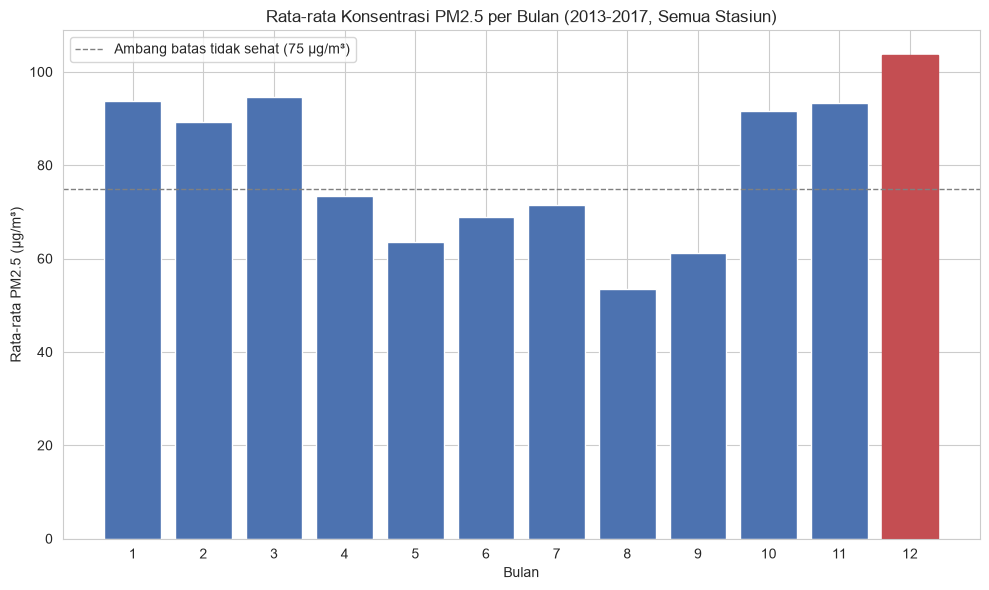

In [11]:
monthly_avg_sorted = df.groupby('month')['PM2.5'].mean()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(monthly_avg_sorted.index, monthly_avg_sorted.values, color='#4C72B0')
max_idx = monthly_avg_sorted.values.argmax()
bars[max_idx].set_color('#C44E52')

ax.set_xticks(range(1, 13))
ax.set_xlabel('Bulan')
ax.set_ylabel('Rata-rata PM2.5 (µg/m³)')
ax.set_title('Rata-rata Konsentrasi PM2.5 per Bulan (2013-2017, Semua Stasiun)')
ax.axhline(75, color='gray', linestyle='--', linewidth=1, label='Ambang batas tidak sehat (75 µg/m³)')
ax.legend()
plt.tight_layout()
plt.show()

### Pertanyaan 2:

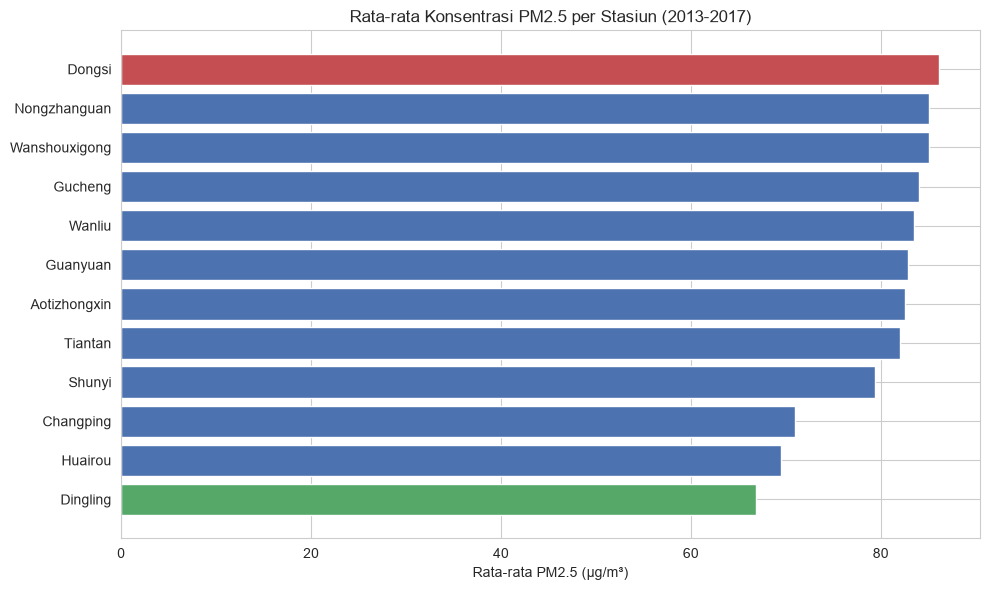

In [12]:
station_avg_sorted = df.groupby('station')['PM2.5'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#C44E52' if v == station_avg_sorted.max() else ('#55A868' if v == station_avg_sorted.min() else '#4C72B0') for v in station_avg_sorted.values]
ax.barh(station_avg_sorted.index[::-1], station_avg_sorted.values[::-1], color=colors[::-1])
ax.set_xlabel('Rata-rata PM2.5 (µg/m³)')
ax.set_title('Rata-rata Konsentrasi PM2.5 per Stasiun (2013-2017)')
plt.tight_layout()
plt.show()

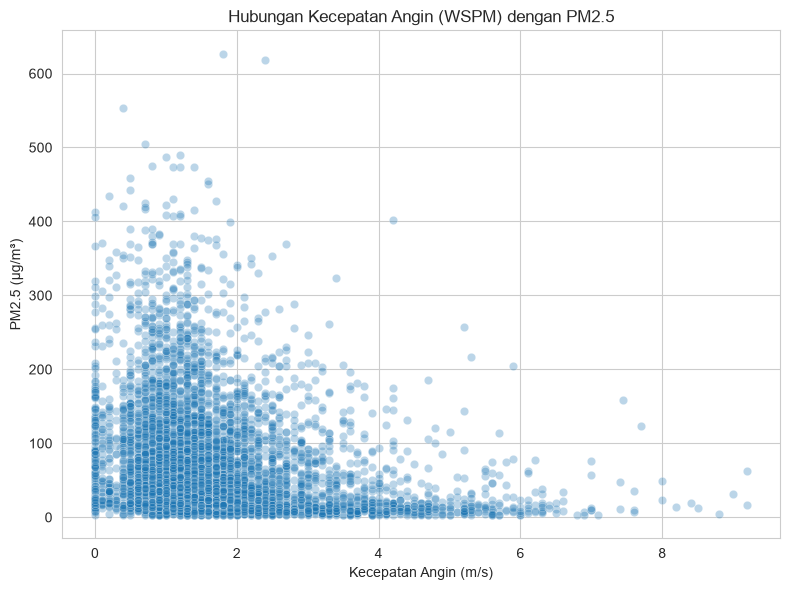

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))
sample = df.sample(5000, random_state=42)
sns.scatterplot(data=sample, x='WSPM', y='PM2.5', alpha=0.3, ax=ax)
ax.set_title('Hubungan Kecepatan Angin (WSPM) dengan PM2.5')
ax.set_xlabel('Kecepatan Angin (m/s)')
ax.set_ylabel('PM2.5 (µg/m³)')
plt.tight_layout()
plt.show()

**Insight:**
- Grafik batang bulanan menunjukkan pola musiman yang jelas: polusi memuncak pada musim dingin (Desember-Maret) dan berada pada titik terendah di pertengahan tahun (Agustus), kemungkinan terkait penggunaan pemanas berbahan bakar fosil yang meningkat saat musim dingin.
- Stasiun Dongsi (area lebih padat/urban) menunjukkan rata-rata PM2.5 tertinggi, sementara Dingling (area pinggiran) terendah.
- Scatter plot menunjukkan pola sebaran yang melebar dan bernilai tinggi saat kecepatan angin rendah, lalu menyempit ke nilai PM2.5 lebih rendah saat kecepatan angin meningkat, mendukung temuan korelasi negatif sebelumnya.

## Analisis Lanjutan (Opsional)

**Clustering Tanpa Machine Learning: Binning Kategori Kualitas Udara**

Teknik ini mengelompokkan setiap data observasi PM2.5 ke dalam kategori kualitas udara standar menggunakan `pd.cut()`, tanpa algoritma machine learning. Tujuannya adalah mengubah angka konsentrasi polutan mentah menjadi kategori yang lebih mudah dipahami dan actionable bagi pembuat kebijakan maupun masyarakat umum.

In [14]:
bins = [0, 15.5, 55.4, 150.4, 250.4, float('inf')]
labels = ['Baik', 'Sedang', 'Tidak Sehat', 'Sangat Tidak Sehat', 'Berbahaya']
df['kategori_udara'] = pd.cut(df['PM2.5'], bins=bins, labels=labels)

df['kategori_udara'].value_counts()

kategori_udara
Tidak Sehat           145447
Sedang                129558
Baik                   81907
Sangat Tidak Sehat     44958
Berbahaya              18898
Name: count, dtype: int64

In [15]:
persentase_kategori = (df['kategori_udara'].value_counts(normalize=True) * 100).round(2)
print("Persentase waktu pada tiap kategori kualitas udara:")
persentase_kategori

Persentase waktu pada tiap kategori kualitas udara:


kategori_udara
Tidak Sehat           34.57
Sedang                30.79
Baik                  19.47
Sangat Tidak Sehat    10.68
Berbahaya              4.49
Name: proportion, dtype: float64

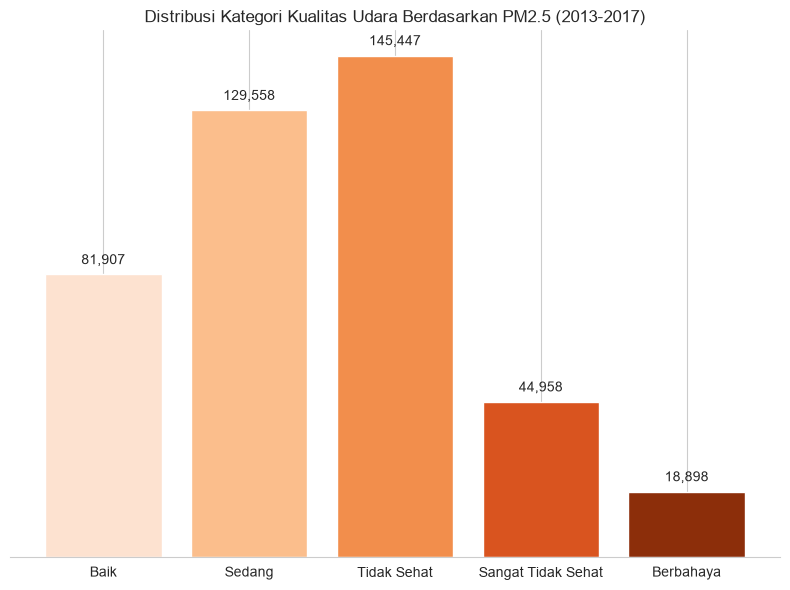

In [16]:
cat_counts = df['kategori_udara'].value_counts().reindex(labels)

fig, ax = plt.subplots(figsize=(8, 6))

# Palet sekuensial: dari terang ke gelap, merepresentasikan keparahan yang meningkat
colors_cat = ['#FDE2D0', '#FBBE8C', '#F28E4C', '#D9541F', '#8C2E0A']

ax.bar(cat_counts.index, cat_counts.values, color=colors_cat)

# Hapus border yang tidak perlu (data-ink ratio)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticks([])  # sumbu-y tidak perlu karena angka sudah ditulis di atas bar

# Tulis angka langsung di atas tiap bar
for i, v in enumerate(cat_counts.values):
    ax.text(i, v + 3000, f'{v:,}', ha='center', fontsize=10)

ax.set_title('Distribusi Kategori Kualitas Udara Berdasarkan PM2.5 (2013-2017)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:**
- Hampir setengah waktu observasi (34,57% Tidak Sehat + 10,68% Sangat Tidak Sehat + 4,49% Berbahaya = **49,74%**) berada pada kategori yang membahayakan kesehatan, menunjukkan bahwa kualitas udara buruk bukan kejadian langka melainkan kondisi yang cukup sering terjadi di seluruh stasiun.
- Kategori "Tidak Sehat" adalah kategori paling dominan (34,57%, 145.447 jam observasi), lebih banyak dari kategori "Baik" (19,47%) dan "Sedang" (30,79%) digabung.
- Binning ini membuat data lebih mudah dikomunikasikan ke non-teknis stakeholder dibandingkan hanya menampilkan angka mentah konsentrasi polutan.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Konsentrasi PM2.5 menunjukkan pola musiman yang jelas, dengan level tertinggi secara konsisten terjadi pada bulan Desember, Januari, Februari, dan Maret (musim dingin), serta level terendah pada bulan Agustus. Rata-rata PM2.5 bulan Desember (103,68 µg/m³) lebih dari 2x lipat dibandingkan bulan Agustus (53,47 µg/m³).

- **Conclusion pertanyaan 2:** Stasiun Dongsi memiliki rata-rata PM2.5 tertinggi (86,14 µg/m³) di antara 12 stasiun, sementara Dingling terendah (66,85 µg/m³). Ditemukan korelasi negatif moderat (-0,27 hingga -0,30) antara kecepatan angin dan PM2.5, mengindikasikan bahwa kondisi angin yang lebih kencang membantu menyebarkan dan menurunkan konsentrasi polutan di udara.

**Rekomendasi Action Item:**
- Pemerintah/otoritas lingkungan disarankan menerapkan kebijakan pembatasan aktivitas yang berpotensi menambah polusi (misalnya pembatasan kendaraan bermotor atau penundaan aktivitas konstruksi) secara lebih ketat selama periode Desember-Maret, mengingat pola musiman polusi yang konsisten selama periode observasi.

- Area di sekitar stasiun Dongsi (dengan rata-rata PM2.5 tertinggi) perlu menjadi prioritas pemasangan sistem peringatan dini kualitas udara serta edukasi masyarakat mengenai penggunaan masker, mengingat hampir separuh waktu observasi berada pada kategori yang membahayakan kesehatan.

- Mengingat korelasi negatif antara kecepatan angin dan PM2.5, informasi prakiraan cuaca (khususnya kecepatan angin rendah) dapat diintegrasikan ke dalam sistem peringatan dini polusi untuk memprediksi hari-hari berisiko tinggi.

In [18]:
# Menyimpan data hasil cleaning untuk digunakan di dashboard
df.to_csv('dashboard/main_data.csv', index=False)